# SVR

[![Slides](https://img.shields.io/badge/🦌-ReHLine-blueviolet)](https://rehline-python.readthedocs.io/en/latest/)

SVR (Support Vector Regression) solves the following optimization problem:

$$
\min_{\beta \in \mathbb{R}^d}
\sum_{i=1}^n \left(\left|y_i-\mathbf{x}_i^\top \beta\right|-\epsilon\right)_+
+\frac{\lambda}{2}\|\beta\|^2
$$

where $\mathbf{x}_i \in \mathbb{R}^d$ is a feature vector, and $y_i \in \mathbb{R}$ is a continuous response variable.

> **Note.** Since the Huber loss is a plq function, we can optimize it using `rehline.plq_Ridge_Regressor`. 
> Moreover, this wrapper adapts the `plqERM_Ridge` into a regressor, compatible with the scikit-learn API.

In [ ]:
## install rehline
%pip install rehline -q

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

In [3]:
# Simulate data
np.random.seed(42)
scaler_svr = StandardScaler()

n, d = 10000, 5
X, y = make_regression(n_samples=n, n_features=d, noise=1.0)
X = scaler_svr.fit_transform(X)
y = y / y.std()

In [4]:
## solve SVR via `plq_Ridge_Regressor`
from rehline import plq_Ridge_Regressor

clf = plq_Ridge_Regressor(loss={"name": "svr", "epsilon": 0.1}, C=1.0)
clf.fit(X=X, y=y)

plq_Ridge_Regressor(loss={'epsilon': 0.1, 'name': 'svr'})

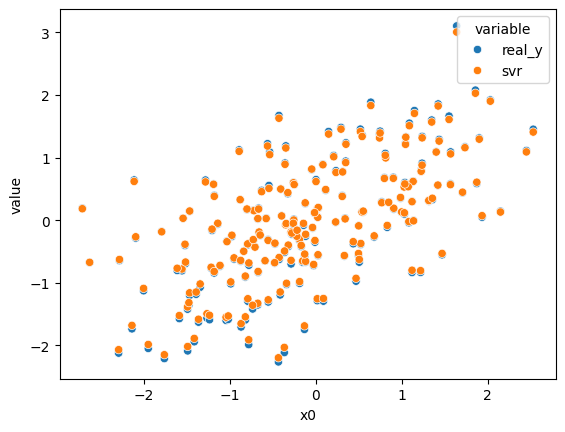

In [5]:
## plot SVR results
warnings.filterwarnings("ignore", "is_categorical_dtype")

n_sample = 200
X_sample, y_sample = X[:n_sample], y[:n_sample]
svr_sample = clf.predict(X_sample)

df = pd.DataFrame({"x0": X_sample[:, 0], "real_y": y_sample, "svr": svr_sample})
df = df.melt(id_vars="x0")

sns.scatterplot(data=df, x="x0", y="value", hue="variable")
plt.show()

## With Pipeline
`plq_Ridge_Regressor` can be integrated into a scikit-learn Pipeline to streamline preprocessing including scaling.

In [6]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [7]:
# Simulate data
np.random.seed(42)

n, d = 10000, 5
X, y = make_regression(n_samples=n, n_features=d, noise=1.0)
y = y / y.std()

In [8]:
## solve SVR via `plq_Ridge_Regressor` with Pipeline
from rehline import plq_Ridge_Regressor

pipe = Pipeline(
    [("scaler", StandardScaler()), ("reg", plq_Ridge_Regressor(loss={"name": "svr", "epsilon": 0.1}, C=1.0))]
)
pipe.fit(X=X, y=y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 plq_Ridge_Regressor(loss={'epsilon': 0.1, 'name': 'svr'}))])

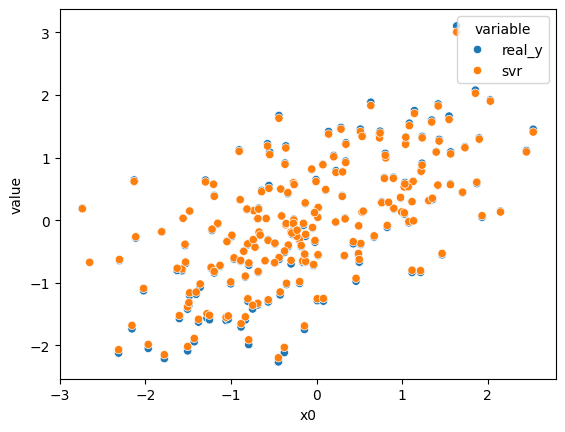

In [9]:
## plot SVR results
warnings.filterwarnings("ignore", "is_categorical_dtype")

n_sample = 200
X_sample, y_sample = X[:n_sample], y[:n_sample]
svr_sample = pipe.predict(X_sample)

df = pd.DataFrame({"x0": X_sample[:, 0], "real_y": y_sample, "svr": svr_sample})
df = df.melt(id_vars="x0")

sns.scatterplot(data=df, x="x0", y="value", hue="variable")
plt.show()

## Hyperparameter Tuning with GridSearchCV

Due to its compatibility with the scikit-learn API, `GridSearchCV` can be applied to determine the optimal hyperparameters for the ReHLine model.

In [10]:
import warnings

from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore")

# Define the parameter grid to search
param_grid = {"reg__C": [0.1, 1.0, 10.0]}

# Use mse to evaluate the performances
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Create the GridSearchCV objects
grid_svr = GridSearchCV(pipe, param_grid, cv=5, scoring=mse_scorer)

grid_svr.fit(X, y)

# Print the best parameters and scores
print(f"Best params:{grid_svr.best_params_}")
print(f"Best CV Score: {-grid_svr.best_score_:.4f}")

Best params:{'reg__C': 1.0}
Best CV Score: 0.0009


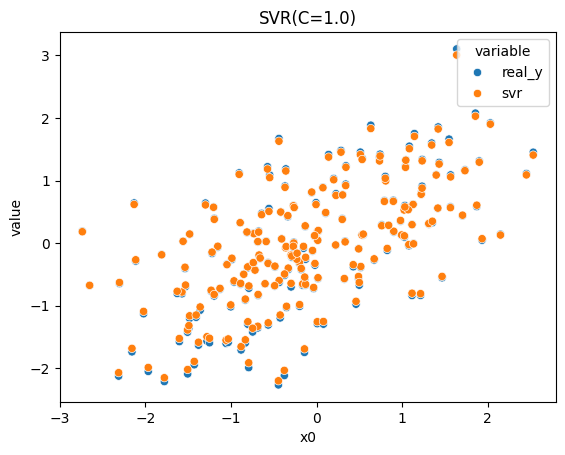

In [11]:
## plot SVR results
n_sample = 200
X_sample, y_sample = X[:n_sample], y[:n_sample]
svr_sample = grid_svr.predict(X_sample)

df = pd.DataFrame({"x0": X_sample[:, 0], "real_y": y_sample, "svr": svr_sample})
df = df.melt(id_vars="x0")

sns.scatterplot(data=df, x="x0", y="value", hue="variable").set_title("SVR(C=1.0)")
plt.show()